# Company Response to Consumer — Target EDA

This notebook explores `company_response_to_consumer` as a potential target variable for predictive modeling.

The analysis focuses on understanding the target distribution, class imbalance, relationships with complaint characteristics, and potential data leakage before model development.

In [ ]:
import google.colab
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
file_path = "/content/drive/MyDrive/Consumer Complain Project/data/processed/complaints_cleaned.parquet"

df = pd.read_parquet(file_path)

print("Cleaned dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset loaded successfully.
Rows: 90112
Columns: 16


## **1. Target Variable Validation**

Before analyzing relationships with other variables, we first inspect the target variable itself to understand its categories, missing values, and overall distribution.

In [ ]:
target = "company_response_to_consumer"

print("Target variable:", target)
print("Data type:", df[target].dtype)
print("Missing values:", df[target].isna().sum())
print("Unique categories:", df[target].nunique(dropna=False))

Target variable: company_response_to_consumer
Data type: object
Missing values: 15807
Unique categories: 6


In [ ]:
response_distribution = (
    df[target]
    .value_counts(dropna=False)
    .to_frame(name="complaint_count")
)

response_distribution["percentage"] = (
    response_distribution["complaint_count"]
    / len(df) * 100
).round(2)

display(response_distribution)

,complaint_count,percentage
company_response_to_consumer,,
Closed with explanation,50849,56.43
None,15807,17.54
Closed with non-monetary relief,11897,13.20
In progress,9467,10.51
Closed with monetary relief,1576,1.75
Untimely response,516,0.57


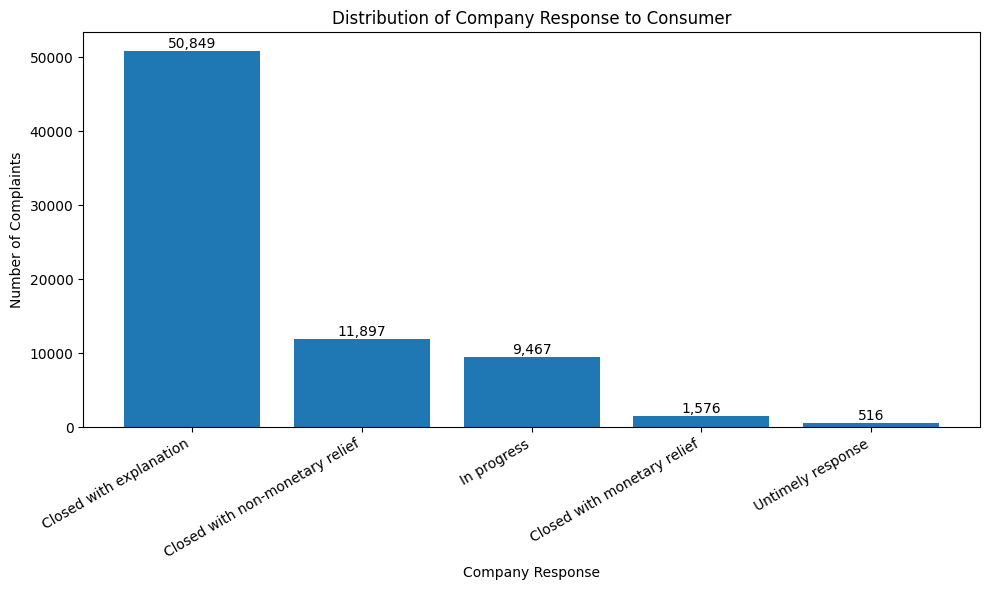

In [ ]:
response_counts = df["company_response_to_consumer"].value_counts()

plt.figure(figsize=(10, 6))

bars = plt.bar(
    response_counts.index,
    response_counts.values
)

plt.title("Distribution of Company Response to Consumer")
plt.xlabel("Company Response")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=30, ha="right")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Checking missing values in the target
missing_target = df["company_response_to_consumer"].isna().sum()

print("Missing target values:", missing_target)
print("Missing percentage:", round(missing_target / len(df) * 100, 2), "%")

Missing target values: 15807
Missing percentage: 17.54 %


In [ ]:
# Show actual non-missing target categories
print("Actual company response categories:")
print("-" * 40)

display(
    df["company_response_to_consumer"]
    .dropna()
    .value_counts()
    .to_frame(name="complaint_count")
)

Actual company response categories:
----------------------------------------


,complaint_count
company_response_to_consumer,
Closed with explanation,50849
Closed with non-monetary relief,11897
In progress,9467
Closed with monetary relief,1576
Untimely response,516


## **2. Missing Target Analysis**

The `company_response_to_consumer` variable contains missing values for a significant portion of complaints.

Before preparing the target for modeling, we investigate whether these missing responses are concentrated within specific complaint characteristics.

In [ ]:
target = "company_response_to_consumer"

target_status = df[target].isna().map({
    True: "Missing",
    False: "Available"
})

target_status_counts = target_status.value_counts()

target_status_distribution = pd.DataFrame({
    "complaint_count": target_status_counts,
    "percentage": (
        target_status_counts / len(df) * 100
    ).round(2)
})

display(target_status_distribution)

,complaint_count,percentage
company_response_to_consumer,,
Available,74305,82.46
Missing,15807,17.54


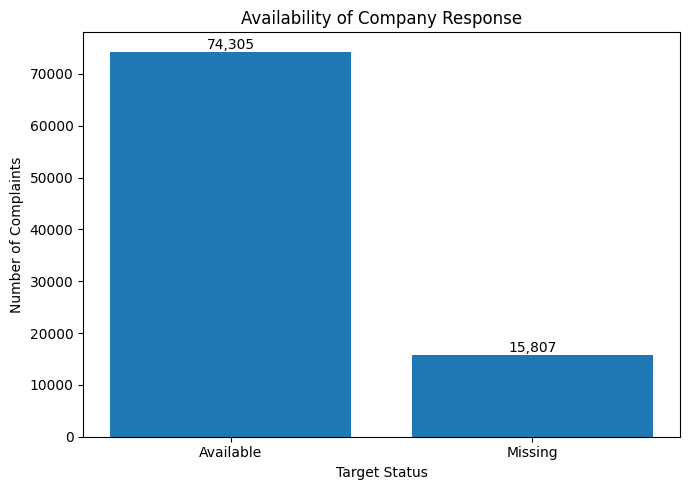

In [ ]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    target_status_counts.index,
    target_status_counts.values
)

plt.title("Availability of Company Response")
plt.xlabel("Target Status")
plt.ylabel("Number of Complaints")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
target_missing_by_product = (
    df.groupby("product")[target]
      .apply(lambda x: x.isna().mean() * 100)
      .sort_values(ascending=False)
      .round(2)
)

display(
    target_missing_by_product.to_frame(
        name="target_missing_percentage"
    )
)

,target_missing_percentage
product,
Other,100.00
Prepaid card,38.05
Debt or credit management,35.11
"Payday loan, title loan, personal loan, or advance loan",23.26
Credit reporting or other personal consumer reports,18.59
Vehicle loan or lease,18.35
Debt collection,17.53
Student loan,16.42
Mortgage,13.03


### Key Findings

- `company_response_to_consumer` is available for 82.46% of complaints and missing for 17.54%.
- Target missingness is not evenly distributed across products.
- The `Other` product category has 100% missing target values.
- `Prepaid card` and `Debt or credit management` also show relatively high target missingness.
- Because the target itself is missing for a substantial and non-uniform portion of the dataset, missing target values should not be imputed without understanding their meaning.
- Further analysis is required before creating the final modeling dataset.

## **2b. Investigating 'In Progress' Complaints**
`company_response_to_consumer` being missing and `== "In progress"` are two different
situations. Missing means no value was ever recorded; In progress means the case is
still open. Before dropping In progress rows for modeling, confirm they behave like
genuinely recent, still-open complaints rather than a data-quality issue.

In [ ]:
in_progress_mask = df[target] == "In progress"
resolved_mask = df[target].notna() & (~in_progress_mask)

print("date_received range — In progress complaints:")
print(df.loc[in_progress_mask, "date_received"].agg(['min', 'max']))
print()
print("date_received range — Resolved complaints:")
print(df.loc[resolved_mask, "date_received"].agg(['min', 'max']))
print()
print("Median date_received — In progress:", df.loc[in_progress_mask, "date_received"].median())
print("Median date_received — Resolved:   ", df.loc[resolved_mask, "date_received"].median())

date_received range — In progress complaints:
min   2026-02-12 01:36:38+00:00
max   2026-07-06 03:54:08+00:00
Name: date_received, dtype: datetime64[ns, UTC]

date_received range — Resolved complaints:
min   2014-07-24 00:33:39+00:00
max   2026-07-04 17:50:02+00:00
Name: date_received, dtype: datetime64[ns, UTC]

Median date_received — In progress: 2026-06-27 05:14:39+00:00
Median date_received — Resolved:    2026-04-28 23:34:31.500000+00:00


### Key Finding — 'In Progress' Complaints

In Progress complaints range from February 2026 to July 2026, with a median date of
late June 2026 — a narrow, recent window. Resolved complaints span 2014 to July 2026,
with an earlier median (April 2026).

This confirms In Progress reflects genuinely open, recently-filed cases that haven't
been finalized yet — not a data-quality gap. It supports excluding these rows from
the modeling target rather than treating them as a class or attempting to impute them.

/tmp/ipykernel_580/3251440066.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df.assign(received_month=df["date_received"].dt.to_period("M"))


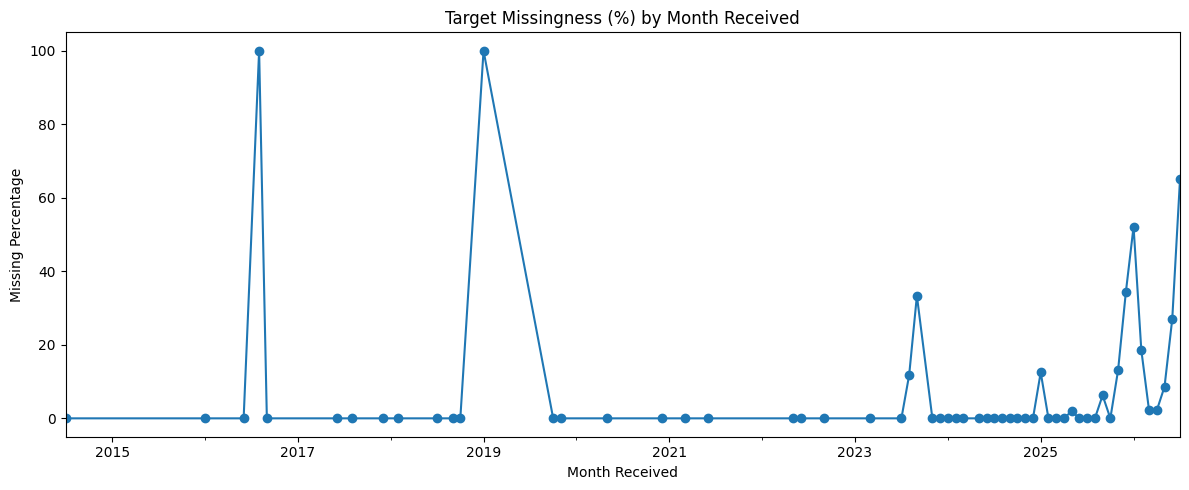

In [ ]:
missing_by_month = (
    df.assign(received_month=df["date_received"].dt.to_period("M"))
      .groupby("received_month")[target]
      .apply(lambda x: x.isna().mean() * 100)
      .round(2)
)

missing_by_month.plot(kind="line", figsize=(12, 5), marker="o")
plt.title("Target Missingness (%) by Month Received")
plt.xlabel("Month Received")
plt.ylabel("Missing Percentage")
plt.tight_layout()
plt.show()

### Key Finding — Missingness Over Time

Missingness stays near 0% for most of the dataset's history (2014–2022), aside from
two isolated spikes to 100% around 2016 and 2019 — likely single months with very
few complaints rather than a real pattern.

From around 2023 onward, and especially from 2025, missingness rises sharply and
becomes volatile, reaching 50–65% in the most recent months. This mirrors the pattern
seen with In Progress complaints: recent complaints are more likely to still be
missing a recorded response simply because they haven't been processed yet.

This supports dropping missing-target rows rather than imputing them, since the
missingness is concentrated in recent, not-yet-resolved complaints rather than being
randomly distributed across the whole dataset.

In [ ]:
# Compare company public response availability between complaints with and without a company response

target_missing_status = df[target].isna()

public_response_by_target = pd.crosstab(
    target_missing_status,
    df["company_public_response"].isna(),
    normalize="index"
).mul(100).round(2)

public_response_by_target.index = [
    "Target Available",
    "Target Missing"
]

public_response_by_target.columns = [
    "Public Response Available",
    "Public Response Missing"
]

display(public_response_by_target)

,Public Response Available,Public Response Missing
Target Available,47.67,52.33
Target Missing,0.00,100.00


### Key Finding — Public Response Availability vs. Target Availability

When `company_response_to_consumer` is missing, `company_public_response` is missing
100% of the time. When the target is available, `company_public_response` is still
missing over half the time (52.33%), so the two aren't perfectly tied together — but
the 100% figure for missing targets is a clean signal.

This reinforces the earlier finding: complaints with a missing target look like cases
the company simply hasn't finished processing yet, consistent with the In Progress
and missingness-over-time patterns already found. It further supports dropping
missing-target rows rather than imputing them.

## **3. Relationship Between Company Response and Timely Response**

This analysis examines the relationship between `company_response_to_consumer` and `timely_response`.

The purpose is to determine whether `timely_response` provides independent predictive information or represents information that becomes available only after the company response process has occurred.

In [ ]:
response_vs_timely = pd.crosstab(
    df["company_response_to_consumer"],
    df["timely_response"],
    normalize="index"
).mul(100).round(2)

display(response_vs_timely)

timely_response,No,Yes
company_response_to_consumer,,
Closed with explanation,1.08,98.92
Closed with monetary relief,1.97,98.03
Closed with non-monetary relief,0.08,99.92
In progress,0.00,100.00
Untimely response,100.00,0.00


In [ ]:
response_vs_timely_count = pd.crosstab(
    df["company_response_to_consumer"],
    df["timely_response"]
)

display(response_vs_timely_count)

timely_response,No,Yes
company_response_to_consumer,,
Closed with explanation,547,50302
Closed with monetary relief,31,1545
Closed with non-monetary relief,9,11888
In progress,0,9467
Untimely response,516,0


### Key Finding — Relationship with Timely Response

A strong relationship was observed between `company_response_to_consumer` and `timely_response`.

All complaints classified as `Untimely response` have `timely_response = No`, while all complaints classified as `In progress` have `timely_response = Yes`.

Because `timely_response` contains information closely associated with the company response outcome, using it as a predictor for `company_response_to_consumer` could introduce target leakage.

Therefore, `timely_response` will not be used as a predictor in the primary model. It may instead be explored as a separate prediction target.

## **4. Company Response by Product**

This analysis examines how company response outcomes vary across different financial products.

The objective is to identify whether certain products are associated with different response outcomes and to determine whether product type may provide useful predictive information.

In [ ]:
response_by_product = pd.crosstab(
    df["product"],
    df["company_response_to_consumer"]
)

display(response_by_product)

company_response_to_consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
product,,,,,
Checking or savings account,3053,568,232,78,14
Credit card,2793,661,358,71,14
Credit reporting or other personal consumer reports,33281,7,9228,8853,26
Debt collection,5923,19,1741,174,143
Debt or credit management,303,14,37,47,24
"Money transfer, virtual currency, or money service",1412,174,96,21,75
Mortgage,1363,27,59,61,19
"Payday loan, title loan, personal loan, or advance loan",763,29,21,33,15
Prepaid card,310,53,36,30,22


In [ ]:
response_by_product_pct = pd.crosstab(
    df["product"],
    df["company_response_to_consumer"],
    normalize="index"
).mul(100).round(2)

display(response_by_product_pct)

company_response_to_consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
product,,,,,
Checking or savings account,77.39,14.40,5.88,1.98,0.35
Credit card,71.67,16.96,9.19,1.82,0.36
Credit reporting or other personal consumer reports,64.76,0.01,17.96,17.23,0.05
Debt collection,74.04,0.24,21.76,2.17,1.79
Debt or credit management,71.29,3.29,8.71,11.06,5.65
"Money transfer, virtual currency, or money service",79.42,9.79,5.40,1.18,4.22
Mortgage,89.14,1.77,3.86,3.99,1.24
"Payday loan, title loan, personal loan, or advance loan",88.62,3.37,2.44,3.83,1.74
Prepaid card,68.74,11.75,7.98,6.65,4.88


> Note: This analysis excludes complaints where `company_response_to_consumer` is missing. Percentages therefore represent the distribution of recorded company responses within each product.

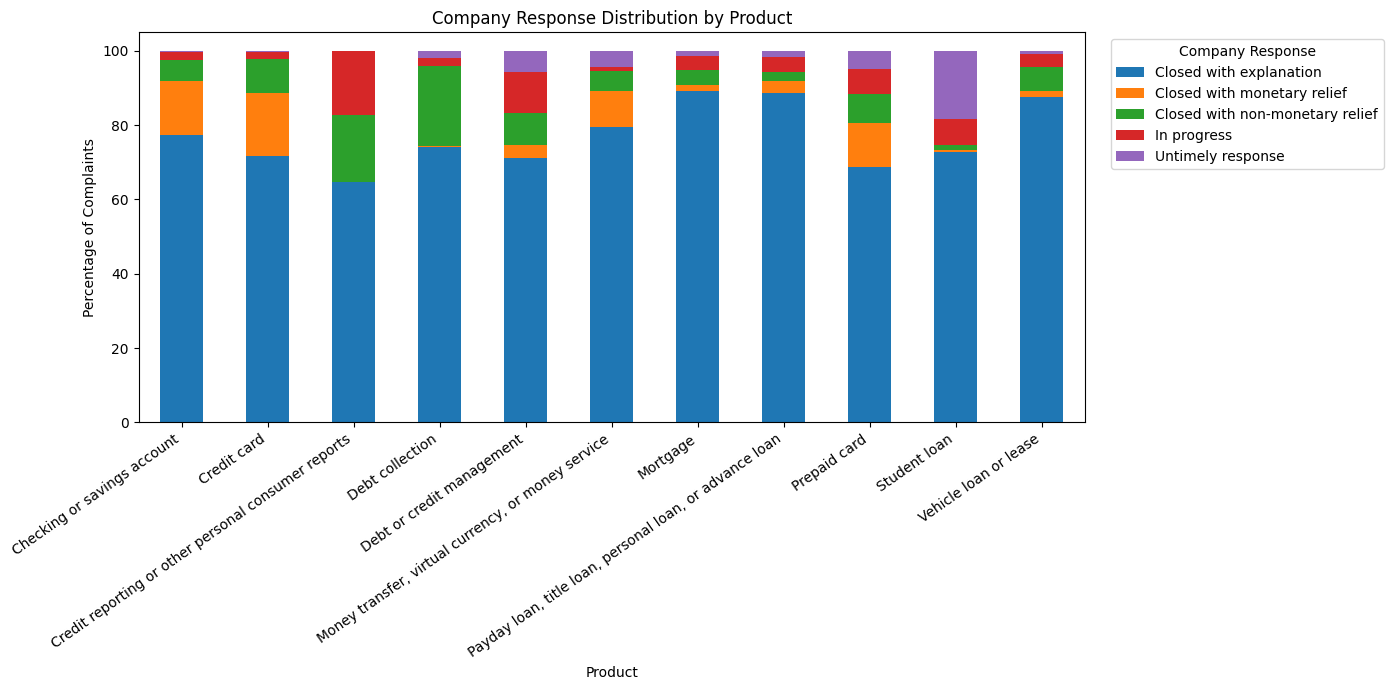

In [ ]:
response_by_product_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Company Response Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Percentage of Complaints")
plt.legend(
    title="Company Response",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Key Findings

- Company response outcomes vary substantially across products.
- Student loan complaints have the highest proportion of recorded untimely responses at 18.22%.
- Debt or credit management also shows a relatively high untimely response proportion of 5.65%.
- Mortgage and vehicle loan complaints have comparatively low untimely response proportions of 1.24% and 0.85%, respectively.
- Credit reporting complaints show relatively high proportions of non-monetary relief (17.96%) and in-progress responses (17.23%), while monetary relief is extremely rare (0.01%).
- Product therefore appears to have a meaningful association with company response outcomes and may provide useful predictive information.
- Percentages are calculated among complaints with a recorded `company_response_to_consumer` value.

In [ ]:
response_by_subproduct = pd.crosstab(
    df["sub_product"],
    df["company_response_to_consumer"]
)

display(response_by_subproduct)

company_response_to_consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
sub_product,,,,,
Auto debt,186,1,34,6,1
CD (Certificate of Deposit),32,5,0,0,0
Check cashing service,25,1,0,0,0
Checking account,2574,494,194,68,8
Conventional home mortgage,704,16,30,32,7
Credit card,1,0,0,0,0
Credit card debt,937,9,282,24,12
Credit repair services,125,2,25,32,6
Credit reporting,33185,7,9195,8818,26


In [ ]:
response_by_subproduct_pct = pd.crosstab(
    df["sub_product"],
    df["company_response_to_consumer"],
    normalize="index"
).mul(100).round(2)

display(response_by_subproduct_pct)

company_response_to_consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
sub_product,,,,,
Auto debt,81.58,0.44,14.91,2.63,0.44
CD (Certificate of Deposit),86.49,13.51,0.00,0.00,0.00
Check cashing service,96.15,3.85,0.00,0.00,0.00
Checking account,77.11,14.80,5.81,2.04,0.24
Conventional home mortgage,89.23,2.03,3.80,4.06,0.89
Credit card,100.00,0.00,0.00,0.00,0.00
Credit card debt,74.13,0.71,22.31,1.90,0.95
Credit repair services,65.79,1.05,13.16,16.84,3.16
Credit reporting,64.78,0.01,17.95,17.21,0.05


### Key Findings

- Company response distributions vary substantially across sub-products.
- International money transfer has a notably high recorded untimely response proportion of 34.57%.
- Federal student loan debt and Federal student loan servicing also show high untimely response proportions of 23.81% and 21.93%, respectively.
- Government benefit card shows a diverse response distribution, including relatively high monetary relief (20.50%), non-monetary relief (17.39%), and untimely response (13.04%).
- Telecommunications debt has a particularly high proportion of non-monetary relief (36.40%).
- Credit reporting has relatively high proportions of non-monetary relief (17.95%) and in-progress responses (17.21%), while untimely responses are rare (0.05%).
- Several sub-products show 100% of recorded responses in a single category. These should be interpreted cautiously because their underlying complaint counts may be small.
- Overall, sub-product appears to have meaningful association with company response outcomes and may provide predictive information.
- Percentages are calculated only among complaints with a recorded `company_response_to_consumer` value.

In [ ]:
subproduct_counts = (
    df["sub_product"]
    .value_counts()
    .rename("complaint_count")
)

subproduct_response_analysis = response_by_subproduct_pct.copy()

subproduct_response_analysis.insert(
    0,
    "complaint_count",
    subproduct_counts
)

display(
    subproduct_response_analysis
    .sort_values("complaint_count", ascending=False)
)

company_response_to_consumer,complaint_count,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
sub_product,,,,,,
Credit reporting,62920,64.78,0.01,17.95,17.21,0.05
I do not know,4993,70.17,0.03,25.29,2.31,2.21
General-purpose credit card or charge card,3646,72.14,16.80,9.08,1.78,0.21
Checking account,3601,77.11,14.80,5.81,2.04,0.24
Credit card debt,1436,74.13,0.71,22.31,1.90,0.95
Other debt,1329,81.91,0.35,14.00,3.04,0.70
Loan,1230,87.24,1.69,6.98,3.59,0.50
Mobile or digital wallet,1006,82.00,9.29,7.68,0.80,0.23
Conventional home mortgage,897,89.23,2.03,3.80,4.06,0.89


### Sample Size Considerations

The response distributions for sub-products should be interpreted together with their complaint counts.

High-volume sub-products such as `Credit reporting` (62,920 complaints), `General-purpose credit card or charge card` (3,646), and `Checking account` (3,601) provide substantially stronger evidence than sub-products with very small sample sizes.

Several low-volume sub-products show 100% concentration in a single response category. These extreme percentages should not be interpreted as stable behavioral patterns because their underlying sample sizes are very small.

Notably, `Federal student loan servicing` shows a high recorded untimely response proportion (21.93%) across 810 complaints, while `Telecommunications debt` has a high non-monetary relief proportion (36.40%) across 522 complaints. `International money transfer` also shows a notably high untimely response proportion (34.57%) across 207 complaints.

Therefore, sub-product appears potentially informative for predicting company response outcomes, but rare categories will require careful treatment during feature engineering and modeling.

In [ ]:
response_by_issue = pd.crosstab(
    df["issue"],
    df["company_response_to_consumer"]
)

display(response_by_issue)

company_response_to_consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
issue,,,,,
"Account opening, closing, or management",1,0,0,0,0
Advertising,4,0,0,1,0
"Advertising and marketing, including promotional offers",154,41,17,3,2
Applying for a mortgage or refinancing an existing mortgage,130,5,6,7,3
Attempts to collect debt not owed,2858,10,999,69,52
...,...,...,...,...,...
Vehicle was damaged or destroyed the vehicle,3,0,0,0,0
Vehicle was repossessed or sold the vehicle,7,0,1,0,0
"Was approved for a loan, but didn't receive the money",3,0,0,0,0


In [ ]:
response_by_issue_pct = pd.crosstab(
    df["issue"],
    df["company_response_to_consumer"],
    normalize="index"
).mul(100).round(2)

display(response_by_issue_pct)

company_response_to_consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
issue,,,,,
"Account opening, closing, or management",100.00,0.00,0.00,0.00,0.00
Advertising,80.00,0.00,0.00,20.00,0.00
"Advertising and marketing, including promotional offers",70.97,18.89,7.83,1.38,0.92
Applying for a mortgage or refinancing an existing mortgage,86.09,3.31,3.97,4.64,1.99
Attempts to collect debt not owed,71.66,0.25,25.05,1.73,1.30
...,...,...,...,...,...
Vehicle was damaged or destroyed the vehicle,100.00,0.00,0.00,0.00,0.00
Vehicle was repossessed or sold the vehicle,87.50,0.00,12.50,0.00,0.00
"Was approved for a loan, but didn't receive the money",100.00,0.00,0.00,0.00,0.00


In [ ]:
issue_response_analysis = pd.crosstab(
    df["issue"],
    df["company_response_to_consumer"],
    normalize="index"
).mul(100).round(2)

issue_target_counts = (
    df.dropna(subset=["company_response_to_consumer"])
      .groupby("issue")
      .size()
      .rename("target_count")
)

issue_response_analysis.insert(
    0,
    "target_count",
    issue_target_counts
)

display(
    issue_response_analysis
    .sort_values("target_count", ascending=False)
)

company_response_to_consumer,target_count,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
issue,,,,,,
Incorrect information on your report,30995,65.48,0.02,17.27,17.14,0.09
Improper use of your report,10685,64.74,0.00,19.33,15.83,0.10
Problem with a company's investigation into an existing problem,10105,63.92,0.11,18.00,17.88,0.09
Attempts to collect debt not owed,3988,71.66,0.25,25.05,1.73,1.30
Managing an account,2168,78.18,13.33,5.81,2.21,0.46
...,...,...,...,...,...,...
Incorrect exchange rate,2,50.00,0.00,0.00,0.00,50.00
Disclosure verification of debt,1,100.00,0.00,0.00,0.00,0.00
Cont'd attempts collect debt not owed,1,100.00,0.00,0.00,0.00,0.00


### Key Findings

- Company response distributions vary across complaint issues.
- The highest-volume issues are primarily related to credit reporting and show substantial proportions of non-monetary relief and in-progress responses.
- `Attempts to collect debt not owed` shows a relatively high proportion of non-monetary relief (25.05%) across a substantial number of recorded responses.
- `Managing an account` shows a relatively high proportion of monetary relief (13.33%).
- Very small issue categories may show extreme percentages, including 100% in a single response category, but these should not be interpreted as stable patterns because of their limited sample sizes.
- Overall, issue appears to contain potentially useful information for predicting `company_response_to_consumer`.
- Response percentages are calculated only among complaints with a recorded target value.

## **5. Company vs Company Response**

This analysis examines whether company response outcomes differ across companies.

The objective is to determine whether company identity provides useful information for predicting `company_response_to_consumer`.

Because the dataset contains many companies, both complaint volume and response distribution will be considered to avoid overinterpreting companies with very few complaints.

In [ ]:
company_counts = (
    df["company"]
    .value_counts()
    .rename("complaint_count")
)

display(company_counts.head(20))

,complaint_count
company,
Experian Information Solutions Inc.,21764
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",19214
"EQUIFAX, INC.",19050
Pending Company Match,3207
"BANK OF AMERICA, NATIONAL ASSOCIATION",1139
CAPITAL ONE FINANCIAL CORPORATION,1032
WELLS FARGO & COMPANY,1005
"CITIBANK, N.A.",966
JPMORGAN CHASE & CO.,794


In [ ]:
response_by_company_pct = pd.crosstab(
    df["company"],
    df["company_response_to_consumer"],
    normalize="index"
).mul(100).round(2)

# Only keep companies that actually have a recorded response (i.e. exist
# in the crosstab), then sort those by their raw complaint volume.
companies_with_response = company_counts.index.intersection(response_by_company_pct.index)
sorted_companies = company_counts.loc[companies_with_response].sort_values(ascending=False).index

response_by_company_pct_sorted = response_by_company_pct.loc[sorted_companies]

display(response_by_company_pct_sorted.head(20))

company_response_to_consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
company,,,,,
Experian Information Solutions Inc.,77.77,0.03,0.21,22.00,0.00
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",58.95,0.00,19.97,21.08,0.00
"EQUIFAX, INC.",56.36,0.00,35.85,7.79,0.00
Pending Company Match,0.00,0.00,0.00,0.00,100.00
"BANK OF AMERICA, NATIONAL ASSOCIATION",63.02,29.29,4.17,3.34,0.19
CAPITAL ONE FINANCIAL CORPORATION,78.82,8.27,10.42,2.49,0.00
WELLS FARGO & COMPANY,77.89,10.74,9.49,1.88,0.00
"CITIBANK, N.A.",57.14,22.53,18.90,1.43,0.00
JPMORGAN CHASE & CO.,80.06,11.28,7.02,1.65,0.00


In [ ]:
company_target_counts = (
    df.dropna(subset=["company_response_to_consumer"])
      .groupby("company")
      .size()
      .rename("target_count")
)

company_response_analysis = response_by_company_pct.copy()

company_response_analysis.insert(
    0,
    "target_count",
    company_target_counts
)

display(
    company_response_analysis
    .sort_values("target_count", ascending=False)
    .head(30)
)

company_response_to_consumer,target_count,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
company,,,,,,
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",17768,58.95,0.00,19.97,21.08,0.00
Experian Information Solutions Inc.,17559,77.77,0.03,0.21,22.00,0.00
"EQUIFAX, INC.",15573,56.36,0.00,35.85,7.79,0.00
"BANK OF AMERICA, NATIONAL ASSOCIATION",1079,63.02,29.29,4.17,3.34,0.19
WELLS FARGO & COMPANY,959,77.89,10.74,9.49,1.88,0.00
"CITIBANK, N.A.",910,57.14,22.53,18.90,1.43,0.00
CAPITAL ONE FINANCIAL CORPORATION,883,78.82,8.27,10.42,2.49,0.00
JPMORGAN CHASE & CO.,727,80.06,11.28,7.02,1.65,0.00
Chime Financial Inc,711,90.01,5.91,1.13,2.95,0.00


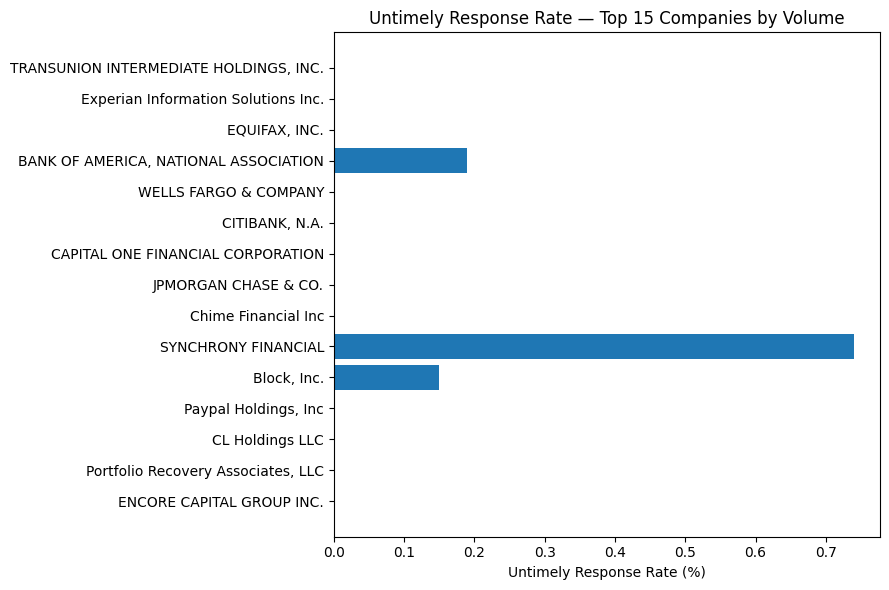

In [37]:
top_companies = (
    company_response_analysis
    .sort_values("target_count", ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
plt.barh(top_companies.index, top_companies["Untimely response"])
plt.xlabel("Untimely Response Rate (%)")
plt.title("Untimely Response Rate — Top 15 Companies by Volume")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Key Findings

- Company response distributions vary substantially across companies.
- Large-volume companies such as TransUnion, Experian, and Equifax show clearly different response distributions, indicating that company identity may contain predictive information.
- Bank of America shows a relatively high proportion of monetary relief (29.29%) compared with many other high-volume companies.
- Portfolio Recovery Associates and CL Holdings LLC show relatively high proportions of non-monetary relief (55.77% and 43.19%, respectively).
- MOHELA shows a notably high proportion of untimely responses (26.59%) across 410 recorded target observations.
- These patterns suggest that `company` may be an informative predictor of `company_response_to_consumer`.
- However, `company` is a high-cardinality categorical variable, so its usefulness and ability to generalize to unseen companies must be evaluated during feature engineering and modeling.
- Company identity itself is available at complaint time, but other company-related response fields may contain post-outcome information and must be evaluated for target leakage.

In [ ]:
response_by_submission = pd.crosstab(
    df["submitted_via"],
    df["company_response_to_consumer"]
)

display(response_by_submission)

company_response_to_consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
submitted_via,,,,,
Phone,152,21,11,21,5
Postal mail,40,0,3,12,0
Referral,66,12,7,14,0
Web,50591,1543,11876,9420,511


In [ ]:
response_by_submission_pct = pd.crosstab(
    df["submitted_via"],
    df["company_response_to_consumer"],
    normalize="index"
).mul(100).round(2)

display(response_by_submission_pct)

company_response_to_consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
submitted_via,,,,,
Phone,72.38,10.00,5.24,10.00,2.38
Postal mail,72.73,0.00,5.45,21.82,0.00
Referral,66.67,12.12,7.07,14.14,0.00
Web,68.42,2.09,16.06,12.74,0.69


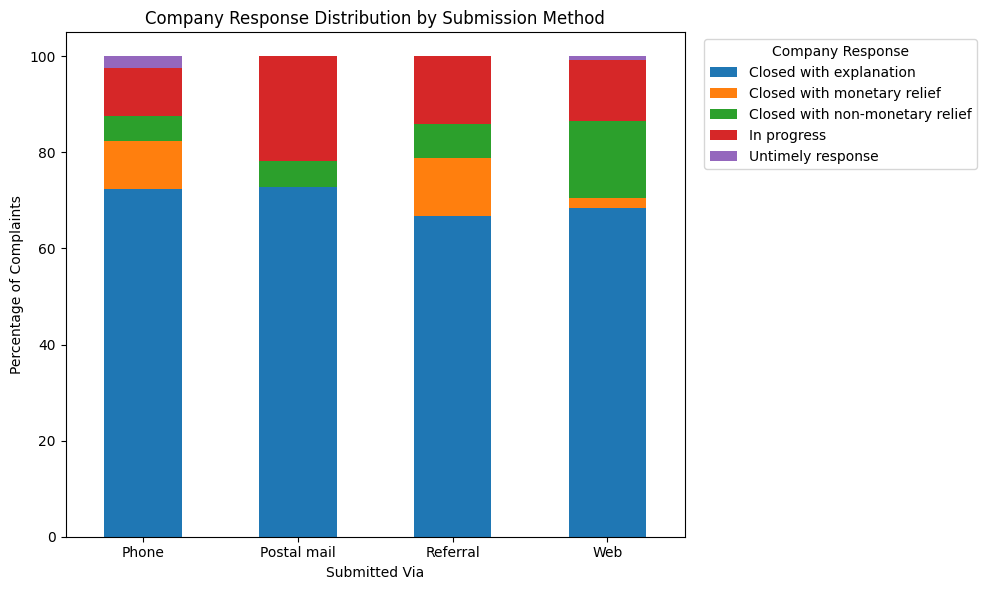

In [38]:
response_by_submission_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Company Response Distribution by Submission Method")
plt.xlabel("Submitted Via")
plt.ylabel("Percentage of Complaints")
plt.legend(title="Company Response", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Key Findings

- Company response distributions vary somewhat across complaint submission methods.
- Web submissions account for the vast majority of recorded responses and show 68.42% closed with explanation, 16.06% closed with non-monetary relief, and 12.74% in progress.
- Postal mail has a relatively high proportion of in-progress responses (21.82%), although its sample size is substantially smaller than Web submissions.
- Referral submissions show 14.14% in-progress responses and 12.12% monetary relief.
- Overall, `submitted_via` shows some association with company response outcomes, although the differences are less pronounced than those observed for variables such as company, product, and issue.
- Since `submitted_via` is available at complaint submission time and has relatively few categories, it remains a reasonable candidate feature for modeling.

In [ ]:
response_by_state = pd.crosstab(
    df["state"],
    df["company_response_to_consumer"]
)

display(response_by_state)

company_response_to_consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
state,,,,,
AA,1,0,0,0,0
AE,10,0,1,1,0
AK,39,0,15,2,0
AL,1325,11,315,272,8
AP,5,0,0,0,0
AR,428,9,97,67,3
AS,2,0,0,0,0
AZ,850,42,191,175,8
CA,4950,277,1149,855,44


In [ ]:
response_by_state_pct = pd.crosstab(
    df["state"],
    df["company_response_to_consumer"],
    normalize="index"
).mul(100).round(2)

display(response_by_state_pct)

company_response_to_consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
state,,,,,
AA,100.00,0.00,0.00,0.00,0.00
AE,83.33,0.00,8.33,8.33,0.00
AK,69.64,0.00,26.79,3.57,0.00
AL,68.62,0.57,16.31,14.09,0.41
AP,100.00,0.00,0.00,0.00,0.00
AR,70.86,1.49,16.06,11.09,0.50
AS,100.00,0.00,0.00,0.00,0.00
AZ,67.14,3.32,15.09,13.82,0.63
CA,68.04,3.81,15.79,11.75,0.60


In [ ]:
state_target_counts = (
    df.dropna(subset=["company_response_to_consumer"])
      .groupby("state")
      .size()
      .rename("target_count")
)

state_response_analysis = response_by_state_pct.copy()

state_response_analysis.insert(
    0,
    "target_count",
    state_target_counts
)

display(
    state_response_analysis
    .sort_values("target_count", ascending=False)
)

company_response_to_consumer,target_count,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Untimely response
state,,,,,,
TX,11506,65.94,1.16,17.93,14.28,0.69
FL,9748,68.03,1.58,15.92,13.95,0.51
CA,7275,68.04,3.81,15.79,11.75,0.60
GA,5139,69.49,1.05,16.44,12.45,0.56
NY,3828,69.36,3.37,14.58,11.86,0.84
IL,3020,68.58,1.69,17.25,11.89,0.60
NC,2570,69.14,1.40,15.76,13.27,0.43
PA,2483,69.43,2.05,15.67,12.12,0.72
NJ,2186,68.71,2.65,14.46,13.31,0.87


A table with 50+ states is hard to read geographically. A quick map makes the state-level pattern easier to see at a glance, and doubles as a preview of what could go straight into the dashboard later.

In [39]:
import plotly.express as px

# Only plot states with a reasonably large sample — avoids a map dominated  by one or two complaints in a tiny territory.
state_plot_data = (
    state_response_analysis[state_response_analysis["target_count"] >= 100]
    .reset_index()
)

fig = px.choropleth(
    state_plot_data,
    locations="state",
    locationmode="USA-states",
    color="Untimely response",
    scope="usa",
    color_continuous_scale="Reds",
    title="Untimely Response Rate by State (states with 100+ recorded responses)"
)
fig.show()

### Key Findings — State

Among states with a meaningfully large sample (500+ recorded responses), state-level variation in company response is modest compared to what was seen across products or companies. Indiana (1.55%), Connecticut (1.31%), and Washington (1.19%) show the highest untimely-response rates; Mississippi (0.29%) and South Carolina (0.32%) show the lowest. For monetary relief, Colorado (4.72%) and Massachusetts (4.42%) are highest among high-volume states, while Alabama and Mississippi are lowest (0.57% each). Overall, state does not appear to be as strong a predictor as product, issue, or company.

### Sample Size Considerations

Several states and U.S. territories have very few recorded complaints. Any state
showing 100% concentration in a single response category should not be treated as
a stable pattern unless backed by a reasonably large target_count. Prioritize
interpreting states with the highest complaint volume.

# EDA for company_response_to_consumer is complete.

The analysis examined the target distribution, missing values, class imbalance, and its relationship with major categorical features including product, sub-product, issue, company, submitted channel, and state.

The analysis shows that the target is a highly imbalanced multiclass classification problem, with Closed with explanation being the dominant class and several minority response categories having substantially fewer observations.

Target behavior also varies across products, sub-products, issues, companies, submission channels, and states. However, categories with very small sample sizes should be interpreted cautiously during modeling.

The missing target records will be excluded from supervised training because their actual company response is unknown.

Missing target rows (15,807) will be excluded from supervised training, along with In Progress rows (9,467) — both represent complaints without a known, final outcome.

**Leakage rule:** `timely_response` must be dropped as a feature — Section 3 confirmed `Untimely response` is 100% associated with `timely_response = No`, and `In progress` is 100% associated with `timely_response = Yes`.

**Features carried forward:** product, sub_product, issue, company (frequency/top-N encoded — 1,499 unique values, too high-cardinality for one-hot), submitted_via, state (weak signal, apply low-sample caution).

**Next notebook:** 05_Feature_Engineering.ipynb